In [1]:
!pip install scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load built-in Iris dataset
iris = load_iris()

# Convert to pandas DataFrame
df = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names
)

# Add the target (species) column
df['Species'] = iris.target

# Map numbers to actual species names
df['Species_Name'] = df['Species'].map({
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
})

# Show first 5 rows
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species,Species_Name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
5,5.4,3.9,1.7,0.4,0,Setosa
6,4.6,3.4,1.4,0.3,0,Setosa
7,5.0,3.4,1.5,0.2,0,Setosa
8,4.4,2.9,1.4,0.2,0,Setosa
9,4.9,3.1,1.5,0.1,0,Setosa


In [3]:
# Shape
print("Shape of dataset:", df.shape)

# Basic info
print("\nDataset Info:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# How many flowers of each species?
print("\nSpecies Count:")
print(df['Species_Name'].value_counts())

Shape of dataset: (150, 6)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    int64  
 5   Species_Name       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.6

/tmp/ipykernel_540/458358738.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species_Name', data=df,


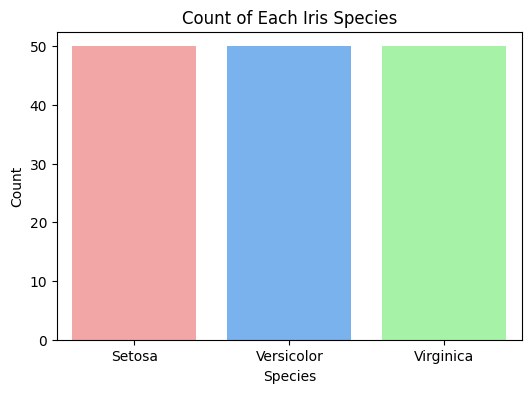

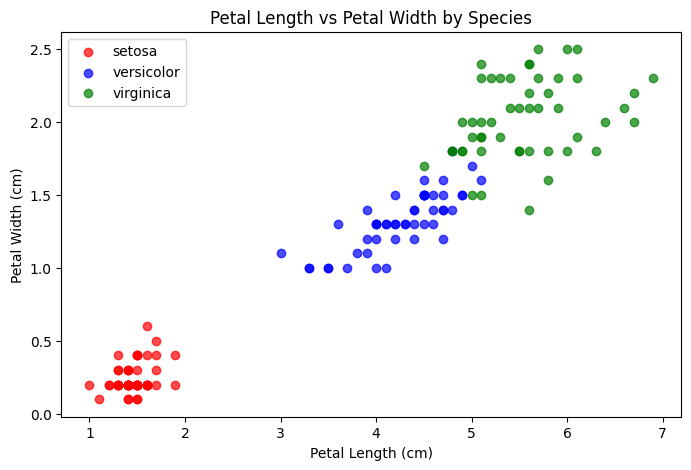

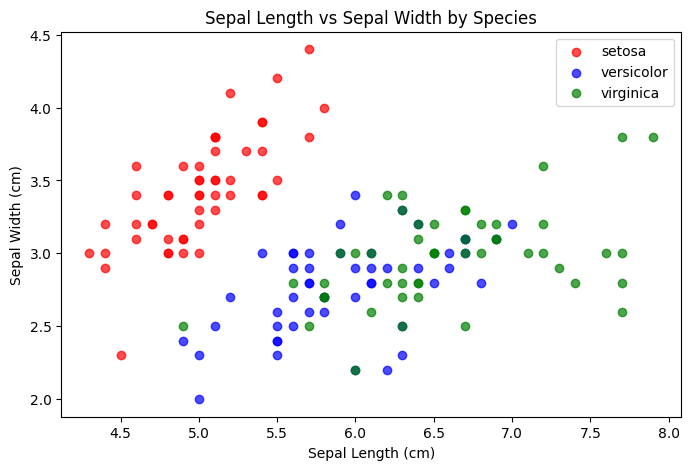

In [4]:
# Chart 1: Count of each species
plt.figure(figsize=(6,4))
sns.countplot(x='Species_Name', data=df,
              palette=['#FF9999','#66B2FF','#99FF99'])
plt.title('Count of Each Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

# Chart 2: Petal Length vs Petal Width
plt.figure(figsize=(8,5))
colors = {0:'red', 1:'blue', 2:'green'}
for species in [0, 1, 2]:
    subset = df[df['Species'] == species]
    plt.scatter(
        subset['petal length (cm)'],
        subset['petal width (cm)'],
        c=colors[species],
        label=iris.target_names[species],
        alpha=0.7
    )
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Petal Length vs Petal Width by Species')
plt.legend()
plt.show()

# Chart 3: Sepal Length vs Sepal Width
plt.figure(figsize=(8,5))
for species in [0, 1, 2]:
    subset = df[df['Species'] == species]
    plt.scatter(
        subset['sepal length (cm)'],
        subset['sepal width (cm)'],
        c=colors[species],
        label=iris.target_names[species],
        alpha=0.7
    )
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Sepal Width by Species')
plt.legend()
plt.show()

<Figure size 1000x800 with 0 Axes>

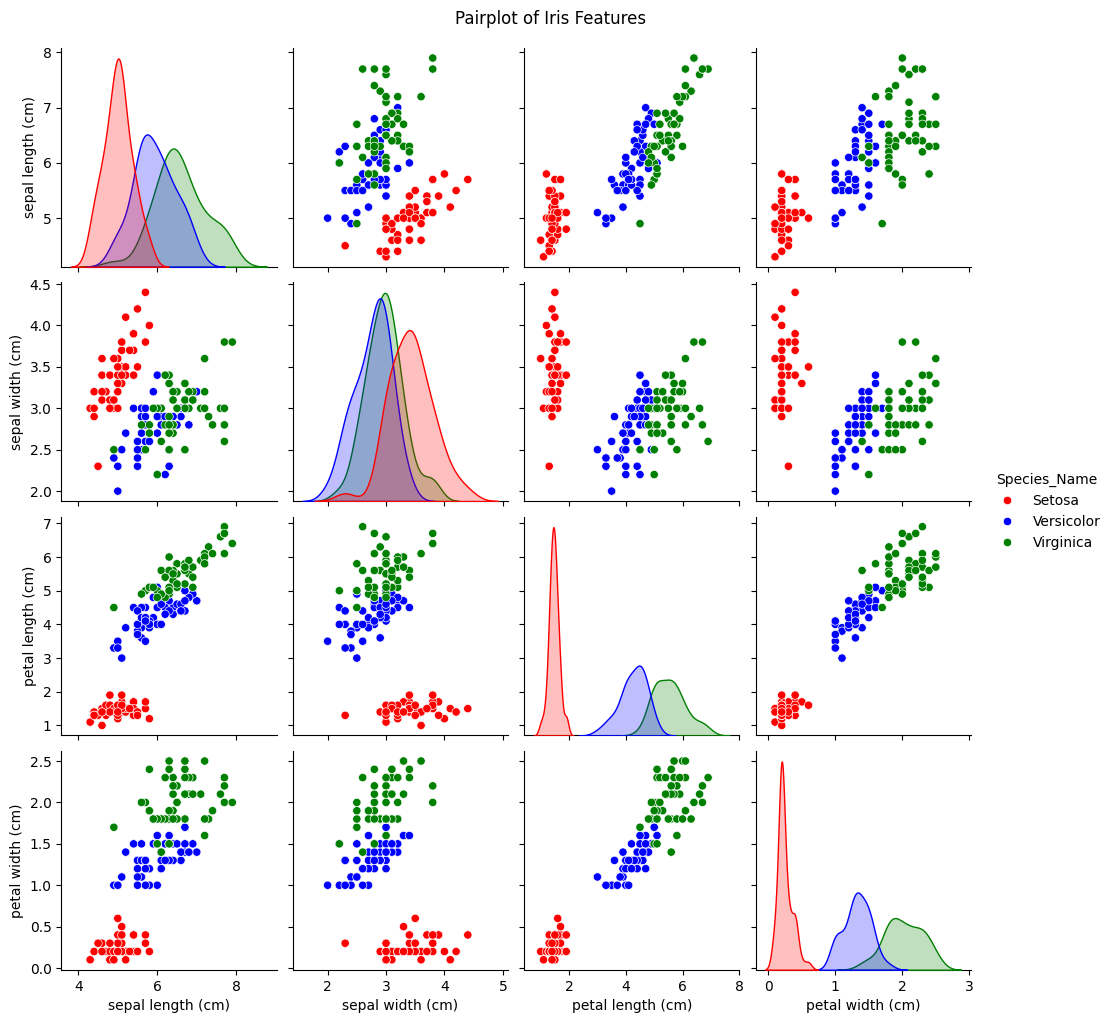

In [5]:
# This shows ALL feature combinations at once
plt.figure(figsize=(10,8))
sns.pairplot(df[['sepal length (cm)',
                  'sepal width (cm)',
                  'petal length (cm)',
                  'petal width (cm)',
                  'Species_Name']],
             hue='Species_Name',
             palette=['red','blue','green'])
plt.suptitle('Pairplot of Iris Features', y=1.02)
plt.show()

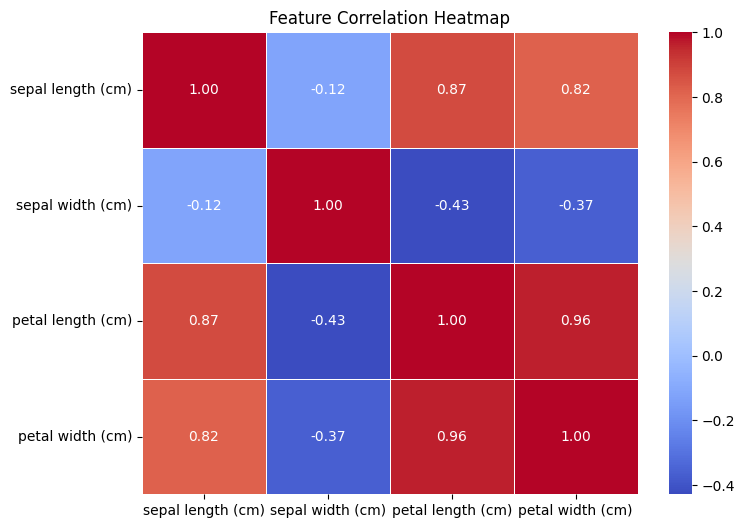

In [6]:
# Which features are most related to each other?
plt.figure(figsize=(8,6))
correlation = df[['sepal length (cm)',
                   'sepal width (cm)',
                   'petal length (cm)',
                   'petal width (cm)']].corr()

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [7]:
# Features (X) and Target (y)
X = df[['sepal length (cm)',
        'sepal width (cm)',
        'petal length (cm)',
        'petal width (cm)']]

y = df['Species']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\n✅ Data ready for training!")

Features (X) shape: (150, 4)
Target (y) shape: (150,)

✅ Data ready for training!


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("✅ Split done!")

Training samples: 120
Testing samples : 30
✅ Split done!


In [9]:
# We will train 4 models and compare them

# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# Model 2: Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

# Model 3: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# Model 4: KNN (K Nearest Neighbors)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print("✅ All 4 models trained!")
print(f"\n📊 Logistic Regression : {lr_acc*100:.2f}%")
print(f"📊 Decision Tree       : {dt_acc*100:.2f}%")
print(f"📊 Random Forest       : {rf_acc*100:.2f}%")
print(f"📊 KNN                 : {knn_acc*100:.2f}%")

✅ All 4 models trained!

📊 Logistic Regression : 100.00%
📊 Decision Tree       : 100.00%
📊 Random Forest       : 100.00%
📊 KNN                 : 100.00%


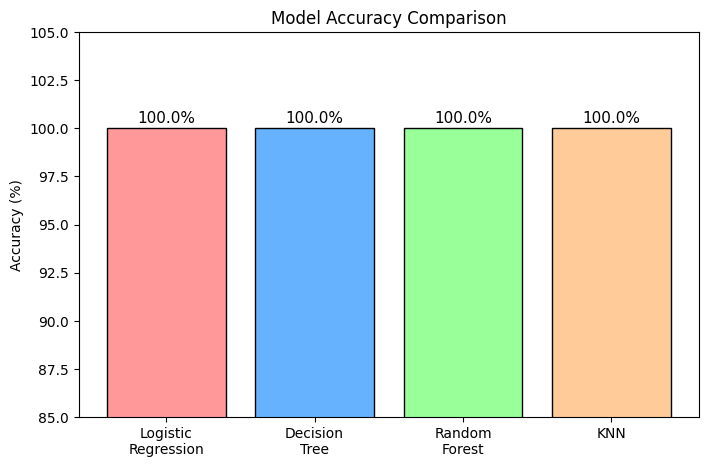

In [10]:
models = ['Logistic\nRegression',
          'Decision\nTree',
          'Random\nForest',
          'KNN']

accuracies = [lr_acc*100, dt_acc*100,
              rf_acc*100, knn_acc*100]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies,
               color=['#FF9999','#66B2FF','#99FF99','#FFCC99'],
               edgecolor='black')

# Add accuracy numbers on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{acc:.1f}%',
             ha='center', fontsize=11)

plt.ylim(85, 105)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.show()

In [11]:
# Using Random Forest as our best model
print("=" * 50)
print("   DETAILED REPORT — RANDOM FOREST MODEL")
print("=" * 50)

print(f"\n🎯 Accuracy: {rf_acc*100:.2f}%")

print("\n📋 Classification Report:")
print(classification_report(
    y_test, rf_pred,
    target_names=['Setosa', 'Versicolor', 'Virginica']
))

   DETAILED REPORT — RANDOM FOREST MODEL

🎯 Accuracy: 100.00%

📋 Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



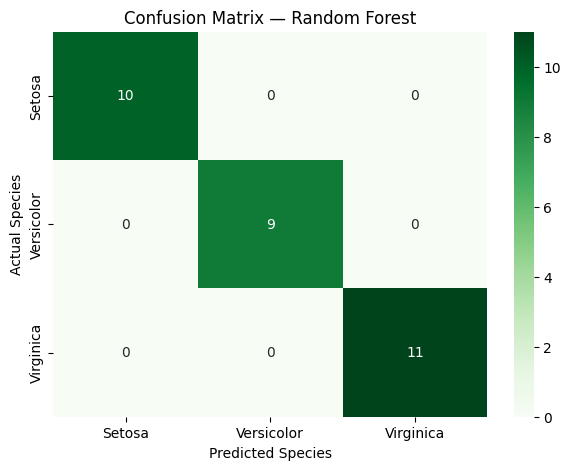

✅ Diagonal numbers = correct predictions!


In [12]:
# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['Setosa','Versicolor','Virginica'],
            yticklabels=['Setosa','Versicolor','Virginica'])
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.show()

print("✅ Diagonal numbers = correct predictions!")

/tmp/ipykernel_540/1386402755.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


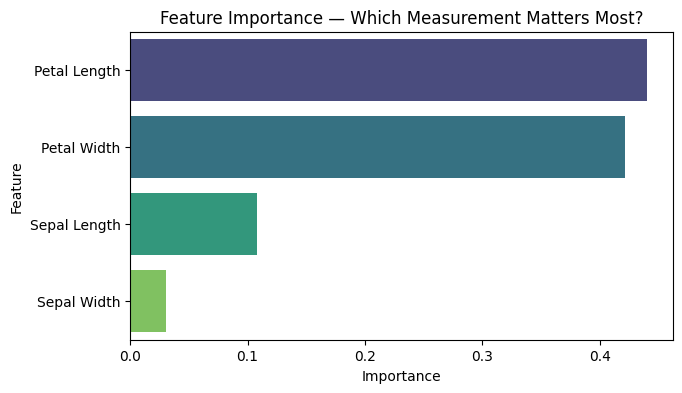

        Feature  Importance
2  Petal Length    0.439994
3   Petal Width    0.421522
0  Sepal Length    0.108098
1   Sepal Width    0.030387


In [13]:
# Which measurement matters most for classification?
feature_names = ['Sepal Length', 'Sepal Width',
                 'Petal Length', 'Petal Width']

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(x='Importance', y='Feature',
            data=importance, palette='viridis')
plt.title('Feature Importance — Which Measurement Matters Most?')
plt.show()

print(importance)

In [14]:
# Predict species of a new flower
# Format: [sepal_length, sepal_width, petal_length, petal_width]

species_names = {0: 'Setosa 🌸',
                 1: 'Versicolor 🌺',
                 2: 'Virginica 🌷'}

# Test flower 1
flower1 = [[5.1, 3.5, 1.4, 0.2]]
pred1 = rf.predict(flower1)
print(f"Flower 1 [5.1, 3.5, 1.4, 0.2] → {species_names[pred1[0]]}")

# Test flower 2
flower2 = [[6.7, 3.0, 5.2, 2.3]]
pred2 = rf.predict(flower2)
print(f"Flower 2 [6.7, 3.0, 5.2, 2.3] → {species_names[pred2[0]]}")

# Test flower 3
flower3 = [[5.8, 2.7, 4.1, 1.0]]
pred3 = rf.predict(flower3)
print(f"Flower 3 [5.8, 2.7, 4.1, 1.0] → {species_names[pred3[0]]}")

Flower 1 [5.1, 3.5, 1.4, 0.2] → Setosa 🌸
Flower 2 [6.7, 3.0, 5.2, 2.3] → Virginica 🌷
Flower 3 [5.8, 2.7, 4.1, 1.0] → Versicolor 🌺


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [15]:
print("=" * 50)
print("         TASK 3 — FINAL SUMMARY")
print("=" * 50)
print(f"Dataset       : Iris Flower Dataset")
print(f"Total Samples : 150 (50 per species)")
print(f"Features Used : 4 measurements")
print(f"Models Tried  : 4")
print("=" * 50)
print(f"Logistic Regression : {lr_acc*100:.2f}%")
print(f"Decision Tree       : {dt_acc*100:.2f}%")
print(f"Random Forest       : {rf_acc*100:.2f}%")
print(f"KNN                 : {knn_acc*100:.2f}%")
print("=" * 50)
best_acc = max(lr_acc, dt_acc, rf_acc, knn_acc)*100
print(f"🏆 Best Accuracy: {best_acc:.2f}%")
print("=" * 50)

         TASK 3 — FINAL SUMMARY
Dataset       : Iris Flower Dataset
Total Samples : 150 (50 per species)
Features Used : 4 measurements
Models Tried  : 4
Logistic Regression : 100.00%
Decision Tree       : 100.00%
Random Forest       : 100.00%
KNN                 : 100.00%
🏆 Best Accuracy: 100.00%
